<a href="https://colab.research.google.com/github/ouerghiwaliddev/AWS-Serverless-Image-Processing-Pipeline/blob/main/extraction_formulaire_BNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extraction automatique — Formulaire BNA / AMI Assurances (v2)

| Module | Détail |
|--------|--------|
| **Champs manuscrits** | Nom/prénom, date naissance, CIN, téléphone, adresse, profession, taille, poids |
| **Cases à cocher** | 23 questions médicales OUI/NON + statut Personnel/Client banque |
| **OCR manuscrit** | TrOCR (`microsoft/trocr-base-handwritten`) — activable en 1 ligne |
| **Détection checkbox** | Ratio d'encre avec seuil **relatif** (robuste au fond imprimé) |
| **Export** | JSON détaillé + CSV (1 ligne/formulaire) prêt pour Excel / Power BI |

> **Corrections v2** : coordonnées taille/poids corrigées (y 1450→840), q13_sport plus AMBIGU,
> seuil relatif sur les cases, overlap adresse/profession réglé, parsing taille/poids par position.


In [ ]:
import subprocess, sys

def _run(cmd):
    """Exécute silencieusement, ignore les erreurs de code de retour non-0."""
    subprocess.run(cmd, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

_run("pip install -q pymupdf opencv-python-headless pytesseract pillow")
_run("apt-get install -q -y tesseract-ocr tesseract-ocr-fra 2>/dev/null")

import warnings; warnings.filterwarnings("ignore")
print("✓ Dépendances prêtes")


✓ Dépendances prêtes


In [ ]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import fitz
import cv2, numpy as np, re
import pandas as pd
import pytesseract
import json, os
from pathlib import Path
from datetime import datetime
from PIL import Image
import matplotlib.pyplot as plt


DPI = 200
print(f"✓ Tesseract {pytesseract.get_tesseract_version()}  |  langues : {pytesseract.get_languages()}")


✓ Tesseract 4.1.1  |  langues : ['eng', 'fra', 'osd']


## 1. PDF → Images

In [ ]:
def pdf_to_images(pdf_path: str, dpi: int = DPI) -> list:
    """Convertit chaque page du PDF en image OpenCV BGR."""
    doc = fitz.open(pdf_path)
    imgs = []
    for page in doc:
        pix = page.get_pixmap(dpi=dpi)
        arr = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        imgs.append(cv2.cvtColor(arr, cv2.COLOR_RGBA2BGR if pix.n == 4 else cv2.COLOR_RGB2BGR))
    doc.close()
    return imgs


## 2. Template de ROI — coordonnées calibrées à 200 DPI

Format `(page_index, x0, y0, x1, y1)` — index 0 = page 1 (attestation), 1 = page 2, 2 = page 3.

> Si vos scans ont une résolution ou des marges différentes, utilisez l'outil de calibration (section 3).


In [ ]:
# ── Champs texte ─────────────────────────────────────────────────────────────
TEXT_FIELDS = {
    # nom_champ          page  x0    y0    x1    y1
    "nom_prenom":        (1,   700,  455, 1480,  500),
    "date_naissance":    (1,   700,  500, 1480,  545),
    "cin":               (1,   700,  545, 1480,  590),
    "telephone":         (1,   700,  590, 1480,  635),
    "adresse":           (1,   700,  630, 1480,  668),
    "profession":        (1,   700,  668, 1480,  710),
    "taille":            (1,   160,  840, 1400,  910),
    "poids":             (1,   160,  840, 1400,  910),
}

HEADER_CHECKBOXES = {
    "statut_personnel_vs_client": {
        "page": 1,
        "options": {
            "personnel_de_la_banque": (700, 693, 745, 738),
            "client_de_la_banque":    (815, 693, 860, 738),
        },
    }
}

# ── Colonnes OUI/NON : x fixe sur tout le formulaire, seul y varie ───────────
X_OUI = (698, 742)
X_NON = (798, 842)

# ── 23 questions médicales ───────────────────────────────────────────────────
# ⚠ CORRECTION v3 : les cases q10 à q13 pointaient sur le libellé imprimé
# "OUI/NON" au lieu de la case à cocher elle-même, un peu plus bas sur la
# ligne. La section "Pour les femmes" (avant q10) ajoute en plus une ligne
# d'en-tête non comptabilisée dans la v2, ce qui décalait tout ce qui suit.
# Repéré par analyse pixel des captures d'écran fournies (cases réelles
# ~1,5x plus basses que prévu à partir de "Pour les femmes"). Les hauteurs de
# case sont aussi élargies (40 → 55-75 px) pour absorber la marge d'erreur
# résiduelle. q1 à q9 sont inchangées (aucune anomalie visible dessus) ;
# recalibrer avec show_calibration()/preview_rois() si besoin.
QUESTIONS = [
    # (identifiant,                    page, y0,   y1,   libellé)
    ("q1_antecedents_familiaux",        1, 1055, 1100, "Antécédents familiaux (cardiaque/cancer/diabète...)"),
    ("q2_traitement_en_cours",          1, 1158, 1203, "Suit un traitement actuellement"),
    ("q3_maladie_anterieure",           1, 1250, 1295, "Maladie digestive/cardio/respiratoire/etc."),
    ("q4_alcool_quotidien",             1, 1487, 1532, "Consomme alcool quotidiennement"),
    ("q4_fumeur",                       1, 1587, 1632, "Fumeur"),
    ("q5_accident",                     1, 1655, 1700, "Victime d'accident"),
    ("q6_pension_invalidite",           1, 1769, 1814, "Titulaire d'une pension d'invalidité"),
    ("q6_procedure_invalidite",         1, 1869, 1914, "Procédure de mise en invalidité en cours"),
    ("q7_arret_travail_actuel",         1, 1969, 2014, "Actuellement en arrêt de travail"),
    ("q7_interruption_5ans",            1, 2067, 2112, "Interruption travail > 3 sem. (5 dernières années)"),
    ("q8_hospitalisation_10ans",        2,  218,  263, "Hospitalisation / traitement spécialisé (10 ans)"),
    ("q8_transfusion_examens",          2,  368,  413, "Transfusions / examens médicaux (10 ans)"),
    ("q8_serologie_positive",           2,  518,  563, "Sérologie VIH / hépatites positive"),
    ("q9_hospitalisation_prochaine",    2,  705,  745, "Hospitalisation / examens à venir"),
    ("q9_intervention_chirurgicale",    2,  805,  845, "Intervention chirurgicale à venir"),
    # ── corrigé : décalé sous "Pour les femmes" + case (pas le libellé) ──────
    ("q10_grossesse_anterieure",        2,  950, 1010, "Grossesse / accouchement antérieurs compliqués"),
    ("q10_grossesse_en_cours",          2, 1020, 1080, "Grossesse en cours"),
    ("q11_assurance_existante",         2, 1090, 1140, "Titulaire d'une assurance de personnes"),
    ("q11_refus_anterieur",             2, 1197, 1247, "Refus / ajournement / surprime sur contrat antérieur"),
    ("q12_pilote_passager_aerien",      2, 1320, 1385, "Pilote / passager d'engin aérien"),
    ("q12_cycle_a_moteur",              2, 1435, 1495, "Utilise un cycle à moteur"),
    ("q13_sport",                       2, 1525, 1600, "Pratique un sport"),
    ("q13_competition",                 2, 1645, 1710, "Participe à des compétitions"),
]


## 3. Outil de calibration

Utilisez ces fonctions pour **vérifier ou recalibrer** les ROI si vos scans ne s'alignent pas exactement.


In [ ]:
def show_calibration(images, page_idx, y_start=0, y_end=None, step=50):
    """Affiche la page avec une grille de coordonnées pour recalibrer à la main."""
    img = images[page_idx].copy()
    h, w = img.shape[:2]
    y_end = y_end or h
    crop = img[y_start:y_end].copy()
    for x in range(0, w, step):
        cv2.line(crop, (x, 0), (x, crop.shape[0]), (0, 180, 0), 1)
        cv2.putText(crop, str(x), (x+2, 13), cv2.FONT_HERSHEY_SIMPLEX, 0.32, (180, 0, 0), 1)
    for y in range(0, crop.shape[0], step):
        cv2.line(crop, (0, y), (w, y), (0, 180, 0), 1)
        cv2.putText(crop, str(y+y_start), (2, y+11), cv2.FONT_HERSHEY_SIMPLEX, 0.32, (180, 0, 0), 1)
    plt.figure(figsize=(13, 14)); plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title(f"Page {page_idx+1} — grille y={y_start}:{y_end}"); plt.axis("off")
    plt.tight_layout(); plt.show()

def preview_rois(images):
    """Superpose toutes les ROI sur les images pour vérification visuelle."""
    pages = sorted(set(
        [v[0] for v in TEXT_FIELDS.values()] +
        [q[1] for q in QUESTIONS] +
        [HEADER_CHECKBOXES["statut_personnel_vs_client"]["page"]]
    ))
    for p in pages:
        img = images[p].copy()
        # Champs texte
        for name, (pg, x0, y0, x1, y1) in TEXT_FIELDS.items():
            if pg != p or name in ("poids",): continue
            color = (180, 0, 255) if name in ("taille",) else (255, 80, 0)
            cv2.rectangle(img, (x0, y0), (x1, y1), color, 2)
            cv2.putText(img, name, (x0, y0-4), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
        # Cases médicales
        for _, pg, y0, y1, qid in QUESTIONS:
            if pg != p: continue
            cv2.rectangle(img, (X_OUI[0], y0), (X_OUI[1], y1), (0, 120, 255), 2)
            cv2.rectangle(img, (X_NON[0], y0), (X_NON[1], y1), (0, 120, 255), 2)
        # Personnel/client
        if HEADER_CHECKBOXES["statut_personnel_vs_client"]["page"] == p:
            for k, box in HEADER_CHECKBOXES["statut_personnel_vs_client"]["options"].items():
                cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), (0, 200, 80), 2)
        plt.figure(figsize=(9, 13)); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Page {p+1} — ROI superposées"); plt.axis("off"); plt.tight_layout(); plt.show()

# Exemples (décommenter) :
# imgs = pdf_to_images("1.PDF")
# show_calibration(imgs, page_idx=1, y_start=750, y_end=960)   # zone taille/poids
# show_calibration(imgs, page_idx=1, y_start=400, y_end=760)   # champs manuscrits
# preview_rois(imgs)


## 4. Détection des cases à cocher — seuil relatif

**Problème v1** : seuil absolu de 0.03 → `q13_sport` classé AMBIGU car le fond imprimé
élève les deux ratios d'encre uniformément, réduisant leur écart absolu.

**Correctif v2** : seuil **relatif** — la case gagnante doit avoir ≥ 8 % d'encre de *plus
proportionnellement*. Robuste même quand les deux ratios sont élevés.


In [ ]:
def ink_ratio(gray_page: np.ndarray, box: tuple, margin: int = 5) -> float:
    """Fraction de pixels sombres dans une case (hors bord imprimé, marge=5 px)."""
    x0, y0, x1, y1 = box
    roi = gray_page[y0+margin : y1-margin, x0+margin : x1-margin]
    if roi.size == 0:
        return 0.0
    _, th = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return float(th.mean()) / 255.0

def read_checkbox_pair(gray_page: np.ndarray, box_oui: tuple, box_non: tuple) -> dict:
    """
    Compare OUI vs NON.
    Confiance = ok        → écart suffisant (relatif ≥ 8 % OU absolu ≥ 2,5 %)
    Confiance = FAIBLE   → correct mais à vérifier (gap juste sous le seuil)
    reponse   = None     → aucune encre détectée
    """
    MIN_INK  = 0.02
    REL_GAP  = 0.08
    ABS_GAP  = 0.025

    ro = ink_ratio(gray_page, box_oui)
    rn = ink_ratio(gray_page, box_non)

    if max(ro, rn) < MIN_INK:
        return {"reponse": None, "confiance": "aucune encre",
                "ink_oui": round(ro, 3), "ink_non": round(rn, 3)}

    diff_abs = abs(ro - rn)
    diff_rel = diff_abs / max(ro, rn)
    reponse  = "OUI" if ro > rn else "NON"

    if diff_rel >= REL_GAP or diff_abs >= ABS_GAP:
        confiance = "ok"
    else:
        confiance = f"FAIBLE_CONFIANCE (gap_rel={diff_rel:.1%})"

    return {"reponse": reponse, "confiance": confiance,
            "ink_oui": round(ro, 3), "ink_non": round(rn, 3)}

def extract_all_checkboxes(images: list) -> dict:
    results = {}

    for qid, page_idx, y0, y1, label in QUESTIONS:
        gray = cv2.cvtColor(images[page_idx], cv2.COLOR_BGR2GRAY)
        res  = read_checkbox_pair(gray,
                                  (X_OUI[0], y0, X_OUI[1], y1),
                                  (X_NON[0], y0, X_NON[1], y1))
        results[qid] = {"libelle": label, **res}

    # Personnel / Client
    cfg  = HEADER_CHECKBOXES["statut_personnel_vs_client"]
    gray = cv2.cvtColor(images[cfg["page"]], cv2.COLOR_BGR2GRAY)
    ratios = {k: ink_ratio(gray, v) for k, v in cfg["options"].items()}
    best   = max(ratios, key=ratios.get)
    results["statut_personnel_vs_client"] = {
        "libelle":       "Personnel de la banque / Client de la banque",
        "reponse":       best if ratios[best] >= MIN_INK else None,
        "confiance":     "ok" if ratios[best] >= MIN_INK else "aucune encre",
        "ink_personnel": round(ratios["personnel_de_la_banque"], 3),
        "ink_client":    round(ratios["client_de_la_banque"],    3),
    }
    return results

MIN_INK = 0.02


## 5. OCR des champs manuscrits

Deux moteurs disponibles :

| Moteur | Précision manuscrite | Vitesse | Pré-requis |
|--------|---------------------|---------|------------|
| **TrOCR** | ⭐⭐⭐ excellente | lent (~2 s/champ) | `transformers` + `torch` |
| **Tesseract** | ⭐ (mauvais sur cursif) | rapide | `pytesseract` |

> **Recommandation Colab** : activer TrOCR (`USE_TROCR = True`).  
> **Recommandation local / faibles ressources** : `USE_TROCR = False` → valeurs brutes lisibles malgré les erreurs.

### Parsing spécial taille / poids
Les deux valeurs sont sur la **même ligne** du formulaire.  
On lit la ligne entière, on détecte les labels imprimés (`votre taille :`, `votre poids :`)
par bounding-box Tesseract (confiance > 80), puis on isole les valeurs manuscrites qui
se trouvent **entre** et **après** ces labels.


In [ ]:
# ── Moteur TrOCR (lazy load) ─────────────────────────────────────────────────
_trocr_proc  = None
_trocr_model = None

def load_trocr():
    global _trocr_proc, _trocr_model
    if _trocr_model is None:
        print("  Chargement TrOCR (première fois ≈ 30 s)...")
        from transformers import TrOCRProcessor, VisionEncoderDecoderModel
        _trocr_proc  = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
        _trocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
        print("  ✓ TrOCR prêt")
    return _trocr_proc, _trocr_model

# ── Preprocessing commun ─────────────────────────────────────────────────────
def _preprocess(crop_bgr: np.ndarray, scale: int = 2) -> np.ndarray:
    """Dénoise → CLAHE → upscale pour améliorer la lisibilité OCR."""
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY) if crop_bgr.ndim == 3 else crop_bgr.copy()
    gray = cv2.bilateralFilter(gray, 7, 60, 60)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    gray  = clahe.apply(gray)
    return cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

# ── OCR TrOCR ────────────────────────────────────────────────────────────────
def ocr_trocr(crop_bgr: np.ndarray) -> str:
    proc, model = load_trocr()
    pil = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
    px  = proc(images=pil, return_tensors="pt").pixel_values
    ids = model.generate(px, max_new_tokens=32)
    return proc.batch_decode(ids, skip_special_tokens=True)[0].strip()

# ── OCR Tesseract ─────────────────────────────────────────────────────────────
def ocr_tesseract(crop_bgr: np.ndarray, lang: str = "fra", psm: int = 7) -> str:
    gray = _preprocess(crop_bgr)
    return pytesseract.image_to_string(gray, lang=lang, config=f"--psm {psm}").strip()

# ── Parsing taille / poids ────────────────────────────────────────────────────
def _extract_taille_poids(images: list, page_idx: int,
                           x0: int, y0: int, x1: int, y1: int,
                           use_trocr: bool) -> tuple:
    """
    Lit la ligne 'votre taille : [val]  votre poids : [val]'.
    Détecte les labels imprimés via Tesseract (conf > 80) pour localiser les valeurs,
    puis lit chaque valeur avec TrOCR ou Tesseract.
    Retourne (taille_str, poids_str).
    """
    row_bgr = images[page_idx][y0:y1, x0:x1]
    row_up  = _preprocess(row_bgr, scale=2)   # upscale x2 pour meilleure détection des labels

    # Mots imprimés détectés avec haute confiance → pour localiser les labels
    data = pytesseract.image_to_data(
        row_up, config="--psm 6 -l fra", output_type=pytesseract.Output.DICT
    )

    # Colonnes (en coordonnées originales = px/2) des labels 'taille' et 'poids'
    taille_end_x = None   # bord droit du ':' après 'taille'
    poids_start_x = None  # bord gauche du mot 'poids'

    for i, word in enumerate(data["text"]):
        w_clean = word.strip().lower()
        conf    = int(data["conf"][i])
        left    = data["left"][i]  // 2     # retour en coords originales
        right   = (data["left"][i] + data["width"][i]) // 2

        if conf >= 70 and w_clean in ("taille", ":") and taille_end_x is None:
            if w_clean == ":":
                taille_end_x = right + x0   # position dans la page
        if conf >= 70 and w_clean == "poids":
            poids_start_x = left + x0

    # Valeur taille : entre fin du ':' et début de 'poids'
    if taille_end_x and poids_start_x:
        crop_t = images[page_idx][y0:y1, taille_end_x : poids_start_x - 10]
    elif taille_end_x:
        crop_t = images[page_idx][y0:y1, taille_end_x : taille_end_x + 300]
    else:
        crop_t = images[page_idx][y0:y1, x0 + 300 : x0 + 600]   # fallback

    # Valeur poids : à droite du label 'poids :'
    poids_colon_x = None
    if poids_start_x:
        for i, word in enumerate(data["text"]):
            if word.strip() == ":" and data["left"][i]//2 + x0 > poids_start_x:
                poids_colon_x = (data["left"][i] + data["width"][i])//2 + x0
                break
    if poids_colon_x:
        crop_p = images[page_idx][y0:y1, poids_colon_x : poids_colon_x + 300]
    elif poids_start_x:
        crop_p = images[page_idx][y0:y1, poids_start_x + 80 : poids_start_x + 380]
    else:
        crop_p = images[page_idx][y0:y1, x0 + 950 : x0 + 1250]  # fallback

    ocr_fn = ocr_trocr if use_trocr else lambda c: ocr_tesseract(c, psm=7)

    taille = ocr_fn(crop_t) if crop_t.size > 0 else ""
    poids  = ocr_fn(crop_p) if crop_p.size > 0 else ""
    return taille, poids

# ── Extraction de tous les champs texte ──────────────────────────────────────
def extract_all_text_fields(images: list, use_trocr: bool = True) -> dict:
    """
    Lit tous les champs manuscrits.
    use_trocr=True  → TrOCR (recommandé, nécessite transformers+torch)
    use_trocr=False → Tesseract uniquement (valeurs approximatives)
    """
    results     = {}
    poids_done  = False

    for name, (pg, x0, y0, x1, y1) in TEXT_FIELDS.items():
        if name == "poids":
            continue  # traité avec taille
        if name == "taille":
            if not poids_done:
                t, p = _extract_taille_poids(images, pg, x0, y0, x1, y1, use_trocr)
                results["taille"] = t
                results["poids"]  = p
                poids_done = True
            continue

        crop = images[pg][y0:y1, x0:x1]
        results[name] = ocr_trocr(crop) if use_trocr else ocr_tesseract(crop)

    return results

# ── Activation ────────────────────────────────────────────────────────────────
USE_TROCR = True  # ← mettre False si transformers/torch non installés


## 6. Visualisation des crops (diagnostic)

In [ ]:
def show_field_crops(images: list):
    """Affiche chaque ROI de champ texte — vérifier l'alignement avant d'appeler l'OCR."""
    items = [(n, v) for n, v in TEXT_FIELDS.items() if n != "poids"]
    fig, axes = plt.subplots(len(items), 1, figsize=(13, 2.2 * len(items)))
    for ax, (name, (pg, x0, y0, x1, y1)) in zip(axes, items):
        crop = images[pg][y0:y1, x0:x1]
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(f"[page {pg+1}]  {name}  ({x0},{y0})→({x1},{y1})", fontsize=8, loc="left")
        ax.axis("off")
    plt.tight_layout(); plt.show()

# show_field_crops(pdf_to_images("1.PDF"))


## 7. Pipeline complet

In [ ]:
def extract_form(pdf_path: str, use_trocr: bool = USE_TROCR, verbose: bool = True) -> dict:
    """
    Extrait tous les champs d'un PDF de formulaire BNA / AMI Assurances.

    Args:
        pdf_path  : chemin vers le PDF
        use_trocr : True = TrOCR (recommandé), False = Tesseract uniquement
        verbose   : affiche les cases à confiance faible

    Returns:
        dict avec champs_manuscrits, questionnaire_medical, statut, métadonnées.
    """
    print(f"  Extraction : {os.path.basename(pdf_path)}")
    images      = pdf_to_images(pdf_path)
    text_fields = extract_all_text_fields(images, use_trocr=use_trocr)
    checkboxes  = extract_all_checkboxes(images)

    record = {
        "fichier":          os.path.basename(pdf_path),
        "date_extraction":  datetime.now().isoformat(timespec="seconds"),
        "champs_manuscrits": text_fields,
        "questionnaire_medical": {
            qid: v["reponse"]
            for qid, v in checkboxes.items()
            if qid != "statut_personnel_vs_client"
        },
        "statut_personnel_vs_client": checkboxes["statut_personnel_vs_client"]["reponse"],
        "_detail_checkbox": checkboxes,
    }

    if verbose:
        faibles = {k: v for k, v in checkboxes.items() if v["confiance"] != "ok"}
        if faibles:
            print("  ⚠ Cases à vérifier manuellement :")
            for k, v in faibles.items():
                print(f"    {k:40s} → {v['reponse']:4s}  [{v['confiance']}]"
                      f"  oui={v.get('ink_oui','?')}  non={v.get('ink_non','?')}")
        else:
            print("  ✓ Toutes les cases : confiance OK")

    return record


## 8. Export JSON + CSV (traitement par lot)

In [ ]:
def process_folder(folder_path: str, output_dir: str = "output",
                   use_trocr: bool = USE_TROCR) -> tuple:
    """
    Traite tous les PDF d'un dossier.
    Génère extraction_resultats.json et extraction_resultats.csv dans output_dir.
    """
    os.makedirs(output_dir, exist_ok=True)
    pdfs = sorted(Path(folder_path).glob("*.pdf")) + sorted(Path(folder_path).glob("*.PDF"))
    print(f"Dossier : {folder_path}  ({len(pdfs)} fichier(s))")

    all_records = []
    for pdf in pdfs:
        try:
            rec = extract_form(str(pdf), use_trocr=use_trocr)
            all_records.append(rec)
        except Exception as e:
            print(f"  ✗ {pdf.name} : {e}")

    # ── JSON détaillé ──────────────────────────────────────────────────────────
    json_path = os.path.join(output_dir, "extraction_resultats.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(all_records, f, ensure_ascii=False, indent=2)

    # ── CSV plat ───────────────────────────────────────────────────────────────
    flat = []
    for r in all_records:
        row = {"fichier": r["fichier"], "date_extraction": r["date_extraction"]}
        row.update({f"champ_{k}": v for k, v in r["champs_manuscrits"].items()})
        row.update({f"q_{k}": v for k, v in r["questionnaire_medical"].items()})
        row["statut_personnel_vs_client"]   = r["statut_personnel_vs_client"]
        row["nb_cases_faible_confiance"]    = sum(
            1 for v in r["_detail_checkbox"].values() if v["confiance"] != "ok"
        )
        flat.append(row)
    df = pd.DataFrame(flat)
    df.to_csv(os.path.join(output_dir, "extraction_resultats.csv"), index=False, encoding="utf-8-sig")

    print(f"\n✓ {len(all_records)} formulaire(s) traité(s)")
    print(f"  JSON → {json_path}")
    print(f"  CSV  → {os.path.join(output_dir,'extraction_resultats.csv')}")
    return all_records, df


## 9. Exécution

Modifiez `INPUT_PDF` avec le chemin vers votre fichier.


In [ ]:
# ── Cas 1 : un seul PDF ───────────────────────────────────────────────────────
INPUT_PDF = "1.PDF"     # ← adapter : ex. "/content/sample_data/1.PDF"

record = extract_form(INPUT_PDF, use_trocr=USE_TROCR, verbose=True)

print("\n" + "═"*62)
summary = {
    "fichier":           record["fichier"],
    "date_extraction":   record["date_extraction"],
    "champs_manuscrits": record["champs_manuscrits"],
    "statut":            record["statut_personnel_vs_client"],
    "questionnaire":     record["questionnaire_medical"],
}
print(json.dumps(summary, ensure_ascii=False, indent=2))


  Extraction : 1.PDF
  Chargement TrOCR (première fois ≈ 30 s)...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ TrOCR prêt
  ✓ Toutes les cases : confiance OK

══════════════════════════════════════════════════════════════
{
  "fichier": "1.PDF",
  "date_extraction": "2026-07-06T09:01:43",
  "champs_manuscrits": {
    "nom_prenom": "# seven months and later had been",
    "date_naissance": "# ACCLIOSTON \" \" \"",
    "cin": "CONFERENCE agreement to increase the business",
    "telephone": "# not go to",
    "adresse": "\" Campbell",
    "profession": "# being very less expensive for the first ever ever ever ever ever ever ever ever ever ever than the",
    "taille": "Assistant Democrats",
    "poids": "- Feb. Brown"
  },
  "statut": "client_de_la_banque",
  "questionnaire": {
    "q1_antecedents_familiaux": "NON",
    "q2_traitement_en_cours": "NON",
    "q3_maladie_anterieure": "NON",
    "q4_alcool_quotidien": "NON",
    "q4_fumeur": "NON",
    "q5_accident": "NON",
    "q6_pension_invalidite": "NON",
    "q6_procedure_invalidite": "NON",
    "q7_arret_travail_actuel": "NON",
    "q7_inte

In [ ]:
# ── Cas 2 : dossier de PDF (traitement par lot) ───────────────────────────────
FOLDER = "/content/PDF"
records, df = process_folder(FOLDER, output_dir="output", use_trocr=USE_TROCR)
df


Dossier : /content/PDF  (0 fichier(s))

✓ 0 formulaire(s) traité(s)
  JSON → output/extraction_resultats.json
  CSV  → output/extraction_resultats.csv


""


## 10. Contrôle qualité visuel

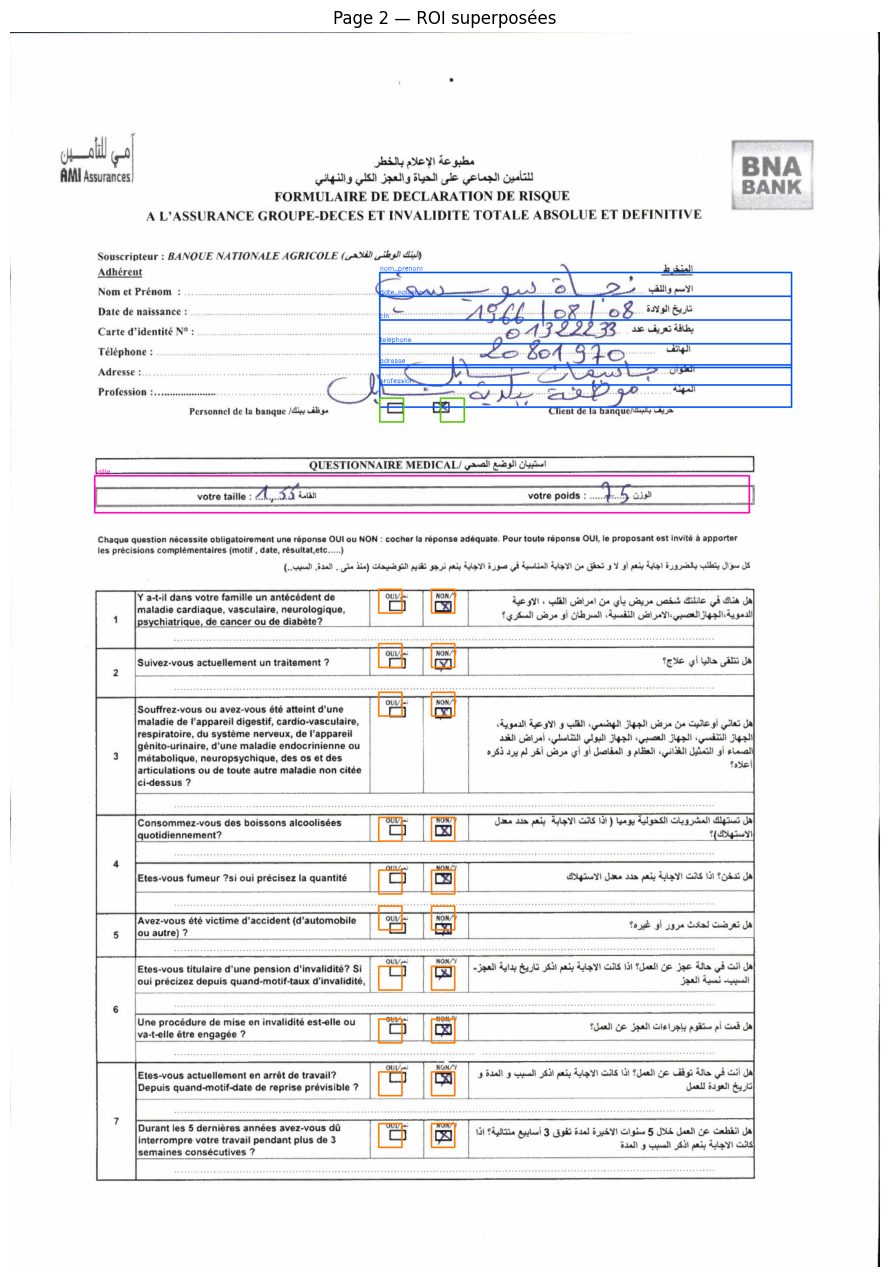

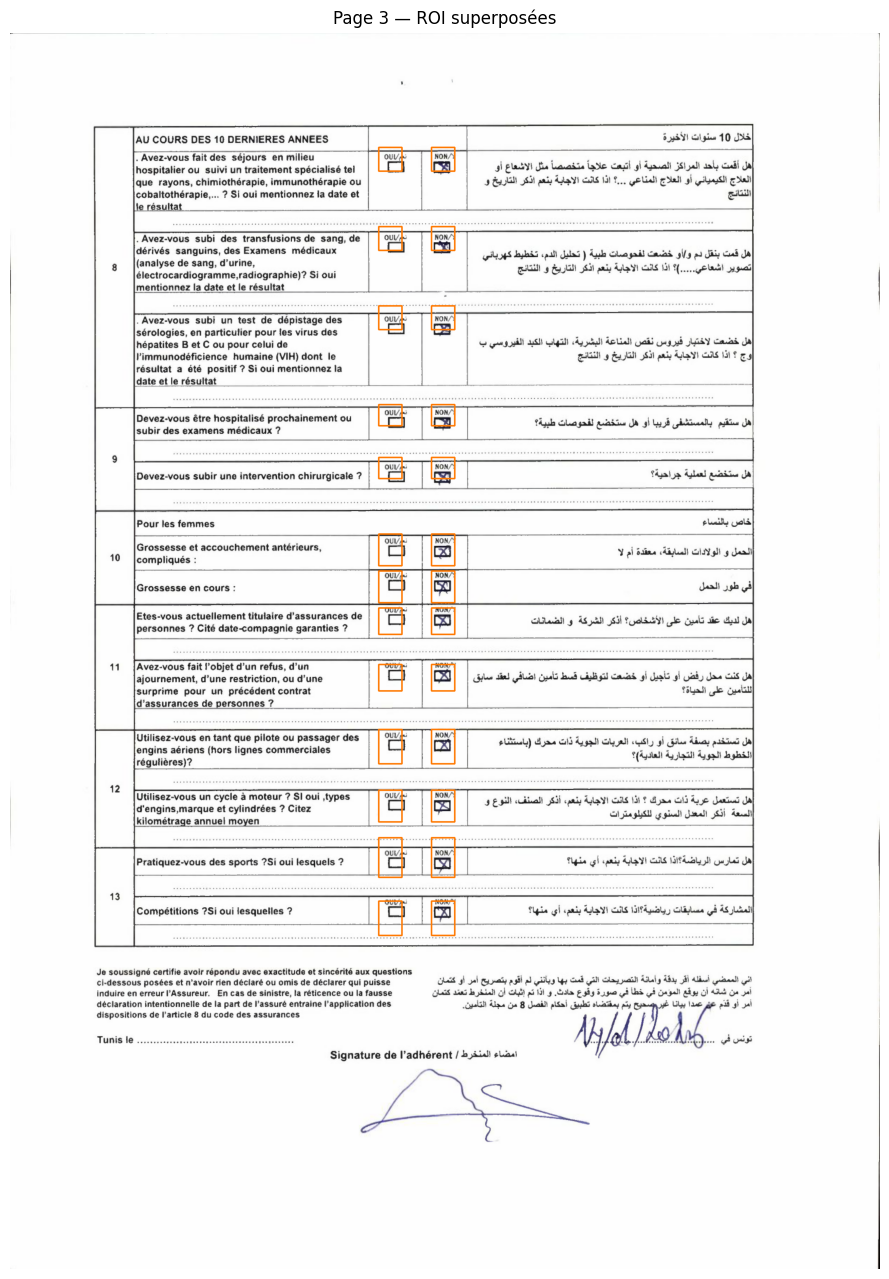

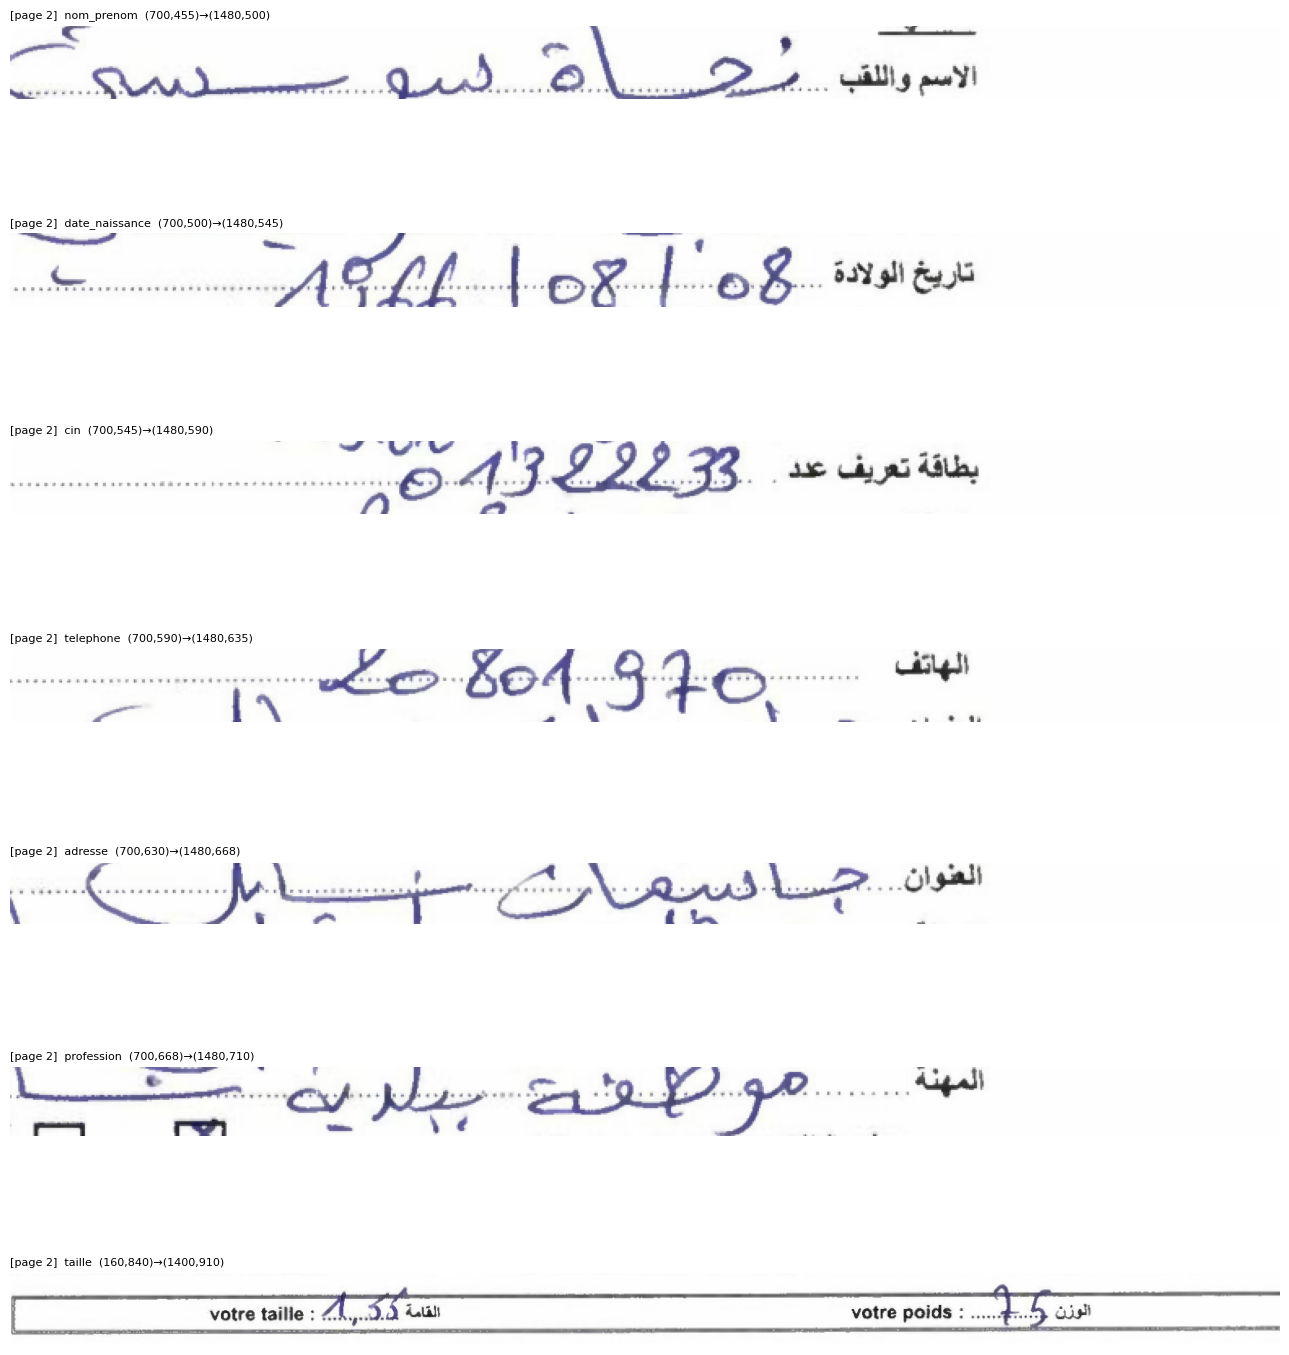


⚠ Cases à faible confiance :
  Aucune — toutes les cases ont une confiance OK ✓


In [ ]:
imgs_qa = pdf_to_images(INPUT_PDF)

# ── ROI superposées ────────────────────────────────────────────────────────────
preview_rois(imgs_qa)

# ── Crops des champs texte ─────────────────────────────────────────────────────
show_field_crops(imgs_qa)

# ── Cases à faible confiance ───────────────────────────────────────────────────
print("\n⚠ Cases à faible confiance :")
faibles = {k: v for k, v in record["_detail_checkbox"].items() if v["confiance"] != "ok"}
if faibles:
    for k, v in faibles.items():
        print(f"  {k:40s} → {v['reponse']:4s}  [{v['confiance']}]"
              f"  oui={v.get('ink_oui','?')}  non={v.get('ink_non','?')}")
else:
    print("  Aucune — toutes les cases ont une confiance OK ✓")


In [ ]:
from google.colab import files
files.download("output/extraction_resultats.json")
files.download("output/extraction_resultats.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>